# Nanosats.eu — Download and parse database

This notebook downloads the HTML from `https://www.nanosats.eu/database`, saves the page into the `data/` folder, parses the table with id `Nanosatellite-Database`, and computes the distinct values in the "Type (U/mass)" column.

Run the code cells in order. The code is written to be robust if the page structure changes slightly (it falls back to finding a table with a 'Mission' header).

In [6]:
# Imports
import requests
from pathlib import Path
from bs4 import BeautifulSoup
import pandas as pd
import sys
import re
import io
from natsort import natsorted
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration
DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
URL = "https://www.nanosats.eu/database"
html_path = DATA_DIR / 'nanosats_eu_database.html'

In [4]:
# Download the page and save to data/
print('Requesting', URL)
resp = requests.get(URL, timeout=30)
resp.raise_for_status()
html_path.write_text(resp.text, encoding='utf-8')
print(f'HTML saved to: {html_path}')

Requesting https://www.nanosats.eu/database
HTML saved to: data/nanosats_eu_database.html


In [33]:
# Parse the saved HTML and locate the satellites table, then compute distinct Type (U/mass) values
html = html_path.read_text(encoding='utf-8')
soup = BeautifulSoup(html, 'lxml')
table_el = soup.find(id='Nanosatellite-Database')

if table_el is None:
    raise RuntimeError('Could not find the Nanosatellite table in saved HTML')

table_html = str(table_el)
dfs = pd.read_html(io.StringIO(table_html), flavor='bs4')

df = dfs[0]
del dfs
df

# Normalize column names
df.columns = [str(c).strip() for c in df.columns]

print(f"{df.shape[0]} missions found in total")

# Show only non-cancelled missions
df = df[df["Launch date"].isin(["x_cancelled", "not launched"]) == False]

print(f"{df.shape[0]} missions have been launched")

4861 missions found in total
3209 missions have been launched


In [27]:
type_col = 'Type (U/mass)'

# Extract distinct values, cleaning whitespace and dropping empties
distinct_vals = (df[type_col].dropna().astype(str).str.strip())
distinct_vals = distinct_vals[distinct_vals.map(lambda x: x not in ('', 'nan', 'None'))]
unique_types = natsorted(distinct_vals.unique())

unique_types
# Save the list to CSV for later use
#out_csv = DATA_DIR / 'nanosats_types_unique.csv'
#pd.Series(unique_types, name=type_col).to_csv(out_csv, index=False, encoding='utf-8')
#print('Saved distinct types to', out_csv)

['0.2 kg',
 '0.3 kg',
 '0.3U',
 '0.5 kg',
 '0.5U',
 '0.6 kg',
 '0.8 kg',
 '0.25U',
 '0.38 kg',
 '0.56 kg',
 '0.127 kg',
 '0.173 kg',
 '0.193 kg',
 '0.234 kg',
 '0.275 kg',
 '0.895 kg',
 '1 kg',
 '1.1 kg',
 '1.4 kg',
 '1.5 kg',
 '1.5U',
 '1U',
 '2.5 kg',
 '2.7 kg',
 '2U',
 '3 kg',
 '3.2 kg',
 '3.5 kg',
 '3.5U',
 '3.7 kg',
 '3.8 kg',
 '3.17 kg',
 '3U',
 '4 kg',
 '4.2 kg',
 '4.5 kg',
 '4U',
 '4U (2Ux2U)',
 '5 kg',
 '5.3 kg',
 '5.5 kg',
 '5U',
 '6 kg',
 '6.5 kg',
 '6.7 kg',
 '6U',
 '6U (1/2 12U XL)',
 '6U (1/2 12U)',
 '6U (1x6U)',
 '7 kg',
 '7.1 kg',
 '7.5 kg',
 '8 kg',
 '8.4 kg',
 '8.5 kg',
 '8.6 kg',
 '8.83 kg',
 '8U',
 '8U (2Ux2Ux2U)',
 '9 kg',
 '9.3 kg',
 '9.7 kg',
 '10 kg',
 '12U',
 '16U',
 '20U',
 '24U (4Ux3Ux2U)',
 '30 g',
 '100 g',
 'FEROX (1/4Ux3Ux2U)',
 'PocketQube 1.5p',
 'PocketQube 1p',
 'PocketQube 2.5p',
 'PocketQube 2p',
 'PocketQube 3p',
 'PocketQube 4p',
 'PocketQube 6p',
 'ThinSat 0.5U',
 'ThinSat 1T',
 'ThinSat 2x1T',
 'ThinSat 3T',
 'ThinSat 5x1T',
 'ThinSat 6T',
 'Thi

In [44]:
# Count how many PocketQubes have been launched
print("PocketQubes launched: ", df[df[type_col].str.contains("PocketQube")].shape[0])

PocketQubes launched:  93


In [29]:
def _heuristic_subcubesat(type: str) -> bool:
    """A function to classify whether a type is considered sub-cubesat"""
    type = type.lower()

    INSTANT_KEYWORDS = [ 'pocketqube', 'suncube', 'thinsat']

    for kw in INSTANT_KEYWORDS:
        if kw in type:
            return True
    
    mass_match = re.search(r'([\d\.]+)\s*(\w+)', type)
    if mass_match:
        mass_kg = float(mass_match.group(1))
        mass_unit = mass_match.group(2)
        if mass_unit == 'g':
            mass_kg /= 1000.0
        elif mass_unit in ['kg', 'u']:
            pass
        else:
            return False
        
        return mass_kg < 1.0

    return False

SUBCUBESAT_TYPES = [ t for t in unique_types if _heuristic_subcubesat(t) ]
NONSUBCUBESAT_TYPES = [ t for t in unique_types if t not in SUBCUBESAT_TYPES ]

print('Sub-cubesat types:')
for t in SUBCUBESAT_TYPES:
    print('-', t)

print('Non sub-cubesat types:')
for t in NONSUBCUBESAT_TYPES:
    print('-', t)


Sub-cubesat types:
- 0.2 kg
- 0.3 kg
- 0.3U
- 0.5 kg
- 0.5U
- 0.6 kg
- 0.8 kg
- 0.25U
- 0.38 kg
- 0.56 kg
- 0.127 kg
- 0.173 kg
- 0.193 kg
- 0.234 kg
- 0.275 kg
- 0.895 kg
- 30 g
- 100 g
- PocketQube 1.5p
- PocketQube 1p
- PocketQube 2.5p
- PocketQube 2p
- PocketQube 3p
- PocketQube 4p
- PocketQube 6p
- ThinSat 0.5U
- ThinSat 1T
- ThinSat 2x1T
- ThinSat 3T
- ThinSat 5x1T
- ThinSat 6T
- ThinSat 6x1T
- ThinSat 8x1T
- ThinSat (2Ux3U)
- ThinSat D+4T
Non sub-cubesat types:
- 1 kg
- 1.1 kg
- 1.4 kg
- 1.5 kg
- 1.5U
- 1U
- 2.5 kg
- 2.7 kg
- 2U
- 3 kg
- 3.2 kg
- 3.5 kg
- 3.5U
- 3.7 kg
- 3.8 kg
- 3.17 kg
- 3U
- 4 kg
- 4.2 kg
- 4.5 kg
- 4U
- 4U (2Ux2U)
- 5 kg
- 5.3 kg
- 5.5 kg
- 5U
- 6 kg
- 6.5 kg
- 6.7 kg
- 6U
- 6U (1/2 12U XL)
- 6U (1/2 12U)
- 6U (1x6U)
- 7 kg
- 7.1 kg
- 7.5 kg
- 8 kg
- 8.4 kg
- 8.5 kg
- 8.6 kg
- 8.83 kg
- 8U
- 8U (2Ux2Ux2U)
- 9 kg
- 9.3 kg
- 9.7 kg
- 10 kg
- 12U
- 16U
- 20U
- 24U (4Ux3Ux2U)
- FEROX (1/4Ux3Ux2U)
- TinySat 1TU
- TinySat 2TU
- TubeSat


In [30]:
import matplotlib as mpl
font_names = mpl.font_manager.get_font_names()
sns.set_theme(style="whitegrid", font="Open Sans")

findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: 

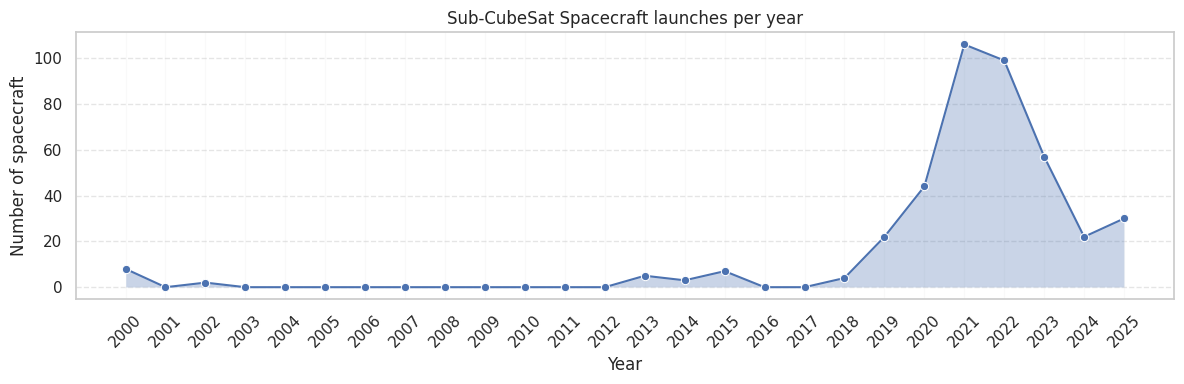

In [11]:
sub_df = df[df[type_col].isin(SUBCUBESAT_TYPES)].copy()

sub_df['launch_date_dt'] = pd.to_datetime(sub_df['Launch date'], errors='coerce')
sub_df['launch_year'] = sub_df['launch_date_dt'].dt.year
sub_df = sub_df.dropna(subset=['launch_year'])
sub_df['launch_year'] = sub_df['launch_year'].astype(int)

counts = sub_df.groupby('launch_year').size().reset_index(name='count').sort_values('launch_year')

min_y, max_y = counts['launch_year'].min(), counts['launch_year'].max()
all_years = pd.DataFrame({'launch_year': range(min_y, max_y + 1)})
counts = all_years.merge(counts, on='launch_year', how='left').fillna(0)
counts['count'] = counts['count'].astype(int)

plt.figure(figsize=(12, 4))
sns.lineplot(data=counts, x='launch_year', y='count', marker='o')
plt.title('Sub-CubeSat Spacecraft launches per year')
plt.xlabel('Year')
plt.ylabel('Number of spacecraft')
plt.xticks(counts['launch_year'], rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.grid(True, axis='x', linestyle='-', alpha=0.1)
plt.fill_between(counts['launch_year'], counts['count'], alpha=0.3)
plt.tight_layout()
plt.savefig('scs_launch_trend.pdf')
plt.show()

In [35]:
df.sort_values("Launch date")

,Mission name,Organisation,Nation,Type (U/mass),Launch date,Status,Mission description,Photo
0,TUBSAT-N,Technical University of Berlin,Germany,8.5 kg,1998-07-07,"Reentered, Was operational",Store and forward communication.,NaN
1,TUBSAT-N1,Technical University of Berlin,Germany,3 kg,1998-07-07,"Reentered, Was operational",Store and forward communication.,NaN
2,"Artemis JAK (MASat, Picosat 5)",Santa Clara University,US,0.2 kg,2000-01-27,No signal,Simple beacon transmitter.,NaN
3,"Artemis Louise (Lightning, Picosat 8)",Santa Clara University,US,0.895 kg,2000-01-27,No signal,Research the effects of lightning on the outer...,NaN
4,"Artemis Thelma (Thunder, Picosat 7)",Santa Clara University,US,0.6 kg,2000-01-27,No signal,Research the effects of lightning on the outer...,NaN
...,...,...,...,...,...,...,...,...
3179,MorSat-1,Amur State University,Russia,6U,2025-12-28,Operational,Monitor the buildup of contaminants inside spa...,NaN
3180,Mule 4T,OKB Fifth Generation,Russia,3U,2025-12-28,"Unknown, ?",Deploy the TriSat picosatellites.,NaN
3181,NasbSat-1,The National Academy of Sciences of Belarus,Belarus,6U,2025-12-28,Operational,NaN,NaN
3172,Grifon 3 (Griffon),Novosibirsk State University (NSU),Russia,6U,2025-12-28,"Unknown, ?",Earth observation constellation with a resolut...,NaN


In [37]:
print("Number of unique countries with nanosatellites: ", df["Nation"].unique().shape[0])

Number of unique countries with nanosatellites:  94
